In [1]:
# (1) 데이터 준비 및 목표가 계산
import pybithumb
import pandas as pd
import numpy as np

# 1. 비트코인 일봉 데이터 가져오기
df = pybithumb.get_ohlcv("BTC")

# 2. 전일 변동폭 계산 (고가 - 저가)
# shift(1)은 데이터를 한 줄 아래로 미루어 '어제의 데이터'를 오늘 행에서 사용하게 합니다.
df['range'] = (df['high'] - df['low']).shift(1)

# 3. 매수 목표가 계산 (당일 시가 + 전일 변동폭 * 0.5)
df['target'] = df['open'] + df['range'] * 0.5

df.head() # 데이터 확인

,open,high,low,close,volume,range,target
time,,,,,,,
2013-12-27,737000.0,755000.0,737000.0,755000.0,3.780000,NaN,NaN
2013-12-28,750000.0,750000.0,750000.0,750000.0,12.000000,18000.0,759000.0
2013-12-29,750000.0,750000.0,728000.0,739000.0,19.058000,0.0,750000.0
2013-12-30,740000.0,772000.0,740000.0,768000.0,9.488973,22000.0,751000.0
2013-12-31,768000.0,800000.0,763000.0,768000.0,18.650350,32000.0,784000.0


In [ ]:
# (2) 수익률(ROR) 계산하기
# 수익률(ROR) 계산
# np.where(조건, 참일때값, 거짓일때값)
# 당일 고가(high)가 목표가(target)보다 높으면 매수 성공 -> 수익률 = 종가 / 목표가
# 아니면 매수 안함 -> 수익률 = 1 (변화 없음)
df['ror'] = np.where(df['high'] > df['target'],
                     df['close'] / df['target'],
                     1)

# 거래 수수료 반영 (빗썸 수수료 약 0.04% 가정 시 0.9996을 곱함)
df['ror'] = df['ror'] * 0.9996 

print(f"최근 시황 수익률:\n{df['ror'].tail()}")

최근 시황 수익률:
time
2026-05-17    0.999600
2026-05-18    0.971614
2026-05-19    0.999600
2026-05-20    1.001298
2026-05-21    0.999138
Name: ror, dtype: float64


최종 누적 수익률: 2719.34%


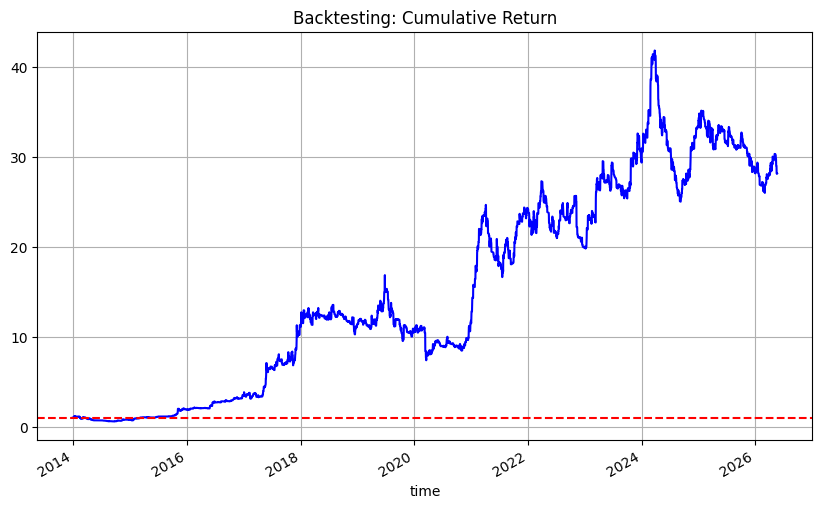

In [4]:
# (3) 누적 수익률(HPR) 계산 및 시각화
# 누적 수익률(Holding Period Return) - cumprod()는 누적 곱셈 함수입니다.
df['hpr'] = df['ror'].cumprod()

# 최종 누적 수익률 출력
final_return = (df['hpr'].iloc[-1] - 1) * 100
print(f"최종 누적 수익률: {final_return:.2f}%")

# 수익률 그래프 그리기
import matplotlib.pyplot as plt
df['hpr'].plot(figsize=(10, 6), title="Backtesting: Cumulative Return", color="blue")
plt.axhline(y=1, color='red', linestyle='--') # 원금 선 표시
plt.grid(True)
plt.show()